# Qwen3-Embedding-4B RQ-VAE SID-v2

PLUM-style SID stage for the audited MovieLens-1M movie embeddings.

- inputs: `meta` and `description` Qwen3-Embedding-4B embeddings
- fusion before RQ quantization, not independent IDs per modality
- residual quantization with 4 compact codebooks
- behavior contrastive positives from weighted PPMI co-occurrence
- best checkpoint is selected by `sid_uniqueness`
- early stopping after 50 epochs without `sid_uniqueness` improvement
- `PROGRESSIVE_SCHEDULE` controls when deeper RQ levels become available
- `PROGRESSIVE_SAMPLING='uniform_prefix'` restores the old stochastic prefix masking logic
- no `description_mask`


In [1]:
from pathlib import Path
import os
import json
import sys

os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

ROOT = Path(r"C:/Users/User/plum-ml1m-repro")
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

FEATURE_PATH = ROOT / "data/processed/item_features/qwen4b_audited_v1_meta_desc_embeddings.npz"
PAIR_PATH = ROOT / "data/processed/sid_pairs/co_pairs_behavior_ppmi_w20_r4_top32.parquet"
TRAIN_PATH = ROOT / "data/processed/splits/train.parquet"
OUTPUT_DIR = ROOT / "runs/qwen4b_rqvae_sid_v2_plum"

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DEVICE

'cuda'

## 1. Load Qwen3-Embedding-4B features and behavior pairs

In [2]:
from src.sid import build_weighted_cooccurrence_pairs, load_feature_bundle

bundle = load_feature_bundle(FEATURE_PATH)

if PAIR_PATH.exists():
    pairs = pd.read_parquet(PAIR_PATH)
else:
    train = pd.read_parquet(TRAIN_PATH)
    pairs = build_weighted_cooccurrence_pairs(
        train,
        output_path=PAIR_PATH,
        window_size=20,
        distance_decay=0.85,
        min_rating=4.0,
        top_k_per_item=32,
    )

{
    "n_items": bundle.n_items,
    "modality_dims": bundle.modality_dims,
    "n_pairs": len(pairs),
    "pair_score_mean": float(pairs["score"].mean()),
}

{'n_items': 3706,
 'modality_dims': {'meta': 2560, 'description': 2560},
 'n_pairs': 110753,
 'pair_score_mean': 5.138205160802714}

## 2. PLUM-style RQ-VAE config

In [3]:
from src.sid import AdvancedRQVAE, RQVAEConfig, count_parameters

model_config = RQVAEConfig(
    modality_dims=bundle.modality_dims,
    latent_dim=256,
    branch_dim=256,
    branch_hidden_dims=(480, 480),
    fusion_hidden_dims=(480, 480),
    decoder_hidden_dims=(480, 480),
    codebook_sizes=(512, 256, 128, 64),
    dropout=0.10,
    use_description_mask=False,
    contrastive_dim=128,
)

model = AdvancedRQVAE(model_config)
n_params = count_parameters(model)
assert n_params < 15_000_000

{
    "n_parameters": n_params,
    "n_parameters_m": round(n_params / 1_000_000, 2),
    "codebook_sizes": model_config.codebook_sizes,
    "n_levels": model_config.n_levels,
}

{'n_parameters': 7324480,
 'n_parameters_m': 7.32,
 'codebook_sizes': (512, 256, 128, 64),
 'n_levels': 4}

## 3. Train

`PROGRESSIVE_SCHEDULE` maps `start_epoch -> max active RQ levels`.

`PROGRESSIVE_SAMPLING` controls how active depth is chosen inside each epoch:
- `deterministic`: always use the scheduled max depth;
- `uniform_prefix`: on every step sample depth uniformly from `1..max_depth`, matching the old RQ-VAE logic.


In [4]:
from src.sid import AdvancedRQVAETrainingConfig, run_advanced_rqvae_experiment

PROGRESSIVE_SCHEDULE = (
    (1, 1),
    (6, 2),
    (12, 3),
    (18, 4),
)
PROGRESSIVE_SAMPLING = "deterministic"  # "deterministic" or "uniform_prefix"

train_config = AdvancedRQVAETrainingConfig(
    seed=42,
    device=DEVICE,
    epochs=400,
    steps_per_epoch=64,
    eval_every=5,
    item_batch_size=256,
    pair_batch_size=256,
    lr=3e-4,
    weight_decay=1e-4,
    beta=0.25,
    contrastive_weight=0.05,
    contrastive_temperature=0.07,
    progressive_masking=True,
    progressive_warmup_epochs=24,
    progressive_schedule=PROGRESSIVE_SCHEDULE,
    progressive_sampling=PROGRESSIVE_SAMPLING,
    eval_pair_sample=10000,
    sid_eval_batch_size=1024,
    early_stopping_patience=50,
    early_stopping_min_delta=0.0,
    show_progress=True,
)

summary = run_advanced_rqvae_experiment(
    bundle=bundle,
    pairs=pairs,
    output_dir=OUTPUT_DIR,
    model_config=model_config,
    train_config=train_config,
)
summary


RQ-VAE:  50%|#####     | 201/400 [07:58<07:54,  2.38s/epoch, loss=0.9498, levels=4, sid=0.9946, best_sid=0.9970, bad_epochs=50]


{'output_dir': 'C:\\Users\\User\\plum-ml1m-repro\\runs\\qwen4b_rqvae_sid_v2_plum',
 'best_epoch': 152,
 'best_sid_uniqueness': 0.9970318402590393,
 'stopped_early': True,
 'stop_reason': 'sid_uniqueness did not improve for 50 consecutive epochs',
 'final_eval': {'n_items': 3706,
  'unique_sids': 3686,
  'sid_uniqueness': 0.9946033459255261,
  'sid_entropy_norm': 0.999055243913426,
  'sid_collision_items': 20,
  'sid_max_multiplicity': 3,
  'per_level_unique': [33, 138, 128, 64],
  'per_level_unique_fraction_codebook': [0.064453125, 0.5390625, 1.0, 1.0],
  'per_level_unique_fraction_items': [0.008904479222881814,
   0.0372369131138694,
   0.03453858607663249,
   0.017269293038316244],
  'per_level_perplexity': [24.644648632591682,
   122.37606534668633,
   123.29596205355764,
   62.12551670510601],
  'per_level_entropy_norm': [0.5136891674481561,
   0.8668972011327307,
   0.9922831059976347,
   0.9928523401122766],
  'per_depth_unique_sids': [33, 1778, 3566, 3686],
  'per_depth_sid_uniq

## 4. Curves

Run after training. The plots read `metrics.json` saved by the trainer.


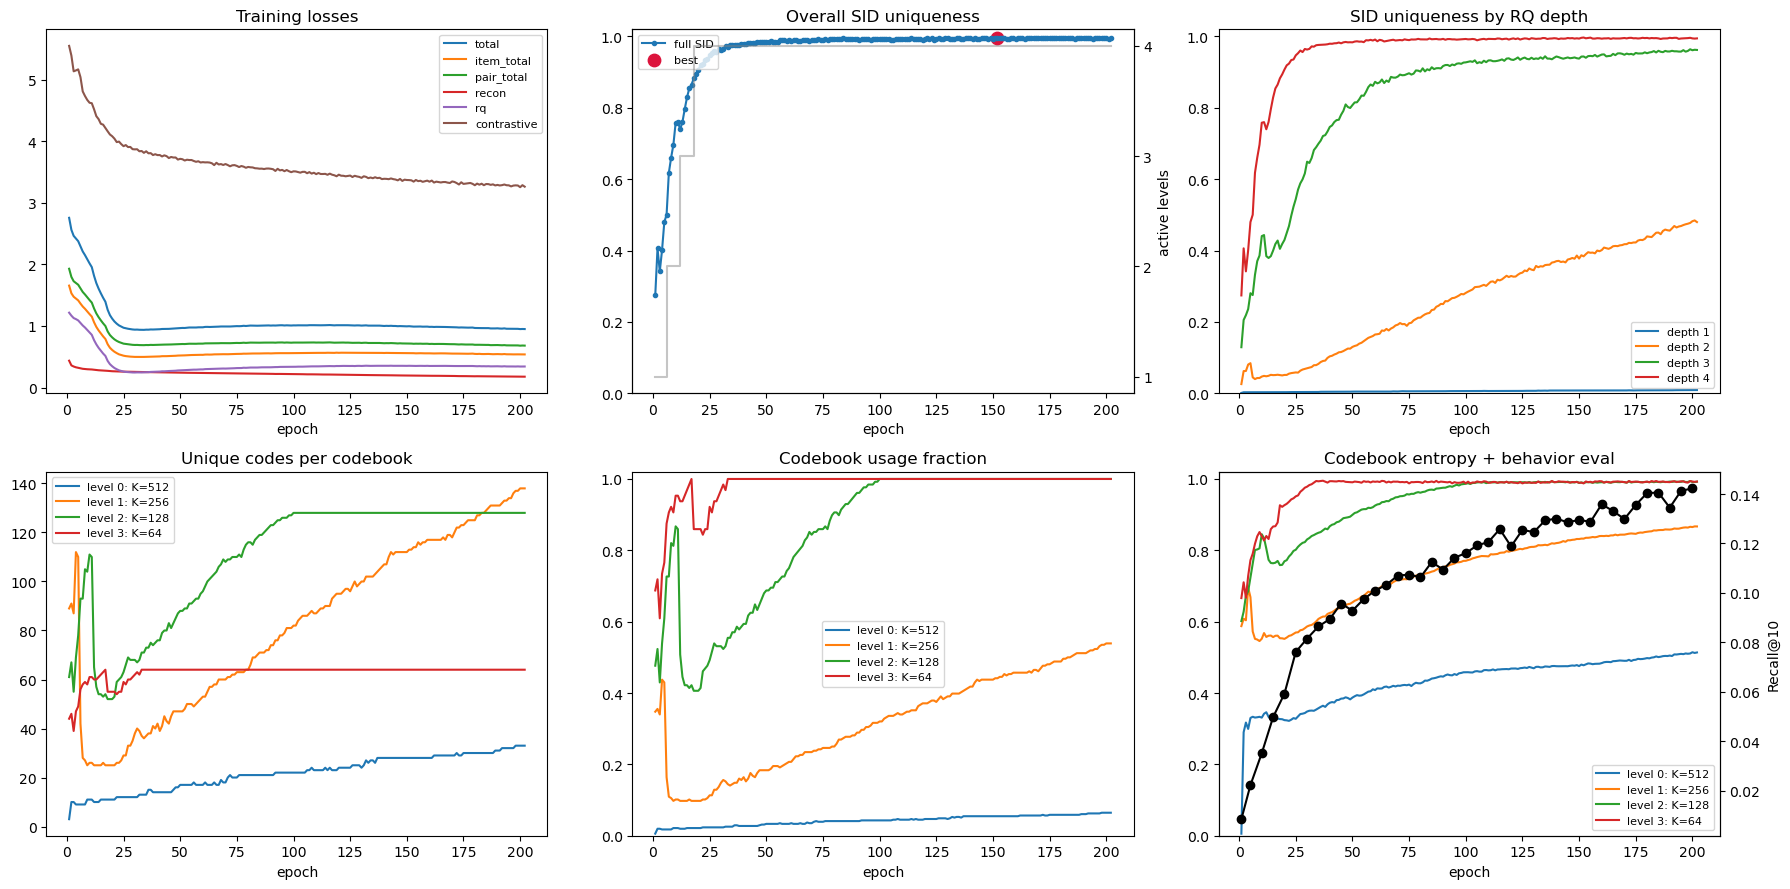

In [5]:
metrics = json.loads((OUTPUT_DIR / "metrics.json").read_text(encoding="utf-8"))
epochs = pd.DataFrame(metrics["epochs"])
evals = pd.json_normalize(metrics["eval"]) if metrics["eval"] else pd.DataFrame()

codebook_labels = [f"level {i}: K={k}" for i, k in enumerate(model_config.codebook_sizes)]
depth_labels = [f"depth {i + 1}" for i in range(len(model_config.codebook_sizes))]
level_unique = pd.DataFrame(epochs["per_level_unique"].tolist(), columns=codebook_labels)
level_usage = pd.DataFrame(epochs["per_level_unique_fraction_codebook"].tolist(), columns=codebook_labels)
level_entropy = pd.DataFrame(epochs["per_level_entropy_norm"].tolist(), columns=codebook_labels)
depth_uniqueness = pd.DataFrame(epochs["per_depth_sid_uniqueness"].tolist(), columns=depth_labels)

fig, axes = plt.subplots(2, 3, figsize=(18, 9))

loss_cols = ["total", "item_total", "pair_total", "recon", "rq", "contrastive"]
for col in loss_cols:
    axes[0, 0].plot(epochs["epoch"], epochs[col], label=col)
axes[0, 0].set_title("Training losses")
axes[0, 0].set_xlabel("epoch")
axes[0, 0].legend(fontsize=8)

axes[0, 1].plot(epochs["epoch"], epochs["sid_uniqueness"], marker="o", markersize=3, label="full SID")
best_idx = epochs["sid_uniqueness"].idxmax()
axes[0, 1].scatter(epochs.loc[best_idx, "epoch"], epochs.loc[best_idx, "sid_uniqueness"], s=80, color="crimson", label="best")
axes[0, 1].set_title("Overall SID uniqueness")
axes[0, 1].set_xlabel("epoch")
axes[0, 1].set_ylim(0, 1.02)
ax_levels = axes[0, 1].twinx()
ax_levels.step(epochs["epoch"], epochs["active_levels"], where="post", color="gray", alpha=0.45, label="active levels")
ax_levels.set_ylabel("active levels")
ax_levels.set_yticks(range(1, len(model_config.codebook_sizes) + 1))
axes[0, 1].legend(fontsize=8, loc="upper left")

for col in depth_labels:
    axes[0, 2].plot(epochs["epoch"], depth_uniqueness[col], label=col)
axes[0, 2].set_title("SID uniqueness by RQ depth")
axes[0, 2].set_xlabel("epoch")
axes[0, 2].set_ylim(0, 1.02)
axes[0, 2].legend(fontsize=8)

for col in codebook_labels:
    axes[1, 0].plot(epochs["epoch"], level_unique[col], label=col)
axes[1, 0].set_title("Unique codes per codebook")
axes[1, 0].set_xlabel("epoch")
axes[1, 0].legend(fontsize=8)

for col in codebook_labels:
    axes[1, 1].plot(epochs["epoch"], level_usage[col], label=col)
axes[1, 1].set_title("Codebook usage fraction")
axes[1, 1].set_xlabel("epoch")
axes[1, 1].set_ylim(0, 1.02)
axes[1, 1].legend(fontsize=8)

for col in codebook_labels:
    axes[1, 2].plot(epochs["epoch"], level_entropy[col], label=col)
if not evals.empty and "contrastive_alignment.behavior_recall_at_10" in evals:
    ax2 = axes[1, 2].twinx()
    ax2.plot(evals["epoch"], evals["contrastive_alignment.behavior_recall_at_10"], color="black", marker="o", label="Recall@10")
    ax2.set_ylabel("Recall@10")
axes[1, 2].set_title("Codebook entropy + behavior eval")
axes[1, 2].set_xlabel("epoch")
axes[1, 2].set_ylim(0, 1.02)
axes[1, 2].legend(fontsize=8)

plt.tight_layout()


## 5. Export SIDs from best checkpoint

In [6]:
from src.sid.training import encode_all_items

ckpt = torch.load(OUTPUT_DIR / "checkpoint_best.pt", map_location=DEVICE)
best_model = AdvancedRQVAE(model_config).to(DEVICE)
best_model.load_state_dict(ckpt["model"])

sids, contrastive, z_q = encode_all_items(best_model, bundle, torch.device(DEVICE), batch_size=1024)

np.save(OUTPUT_DIR / "SIDs_best.npy", sids.astype(np.int64))
pd.DataFrame({
    "item_idx": bundle.item_idx,
    "movie_id": bundle.movie_id,
    **{f"sid_{i}": sids[:, i] for i in range(sids.shape[1])},
}).to_parquet(OUTPUT_DIR / "sid_mapping_best.parquet", index=False)

best_eval = ckpt.get("sid_eval", ckpt.get("eval", {}))
{
    "best_epoch": int(best_eval.get("epoch", -1)),
    "best_sid_uniqueness": float(best_eval.get("sid_uniqueness", np.nan)),
    "sid_shape": sids.shape,
    "unique_sids": int(np.unique(sids, axis=0).shape[0]),
    "output_dir": str(OUTPUT_DIR),
}


C:\Users\User\AppData\Local\Temp\ipykernel_10076\1824750618.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(OUTPUT_DIR / "checkpoint_best.pt", map_loca

{'best_epoch': 152,
 'best_sid_uniqueness': 0.9970318402590393,
 'sid_shape': (3706, 4),
 'unique_sids': 3695,
 'output_dir': 'C:\\Users\\User\\plum-ml1m-repro\\runs\\qwen4b_rqvae_sid_v2_plum'}

## 6. CLI equivalent

In [ ]:
# Same run from terminal:
# python scripts/run_qwen4b_rqvae_sid_v2.py --epochs 400 --early-stopping-patience 50 --progressive-schedule 1:1,6:2,12:3,18:4 --progressive-sampling uniform_prefix --output-dir runs/qwen4b_rqvae_sid_v2_plum
